In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
print("All libraries imported successfully")

All libraries imported successfully


# Multiple Regression Practice

**house_price_regression.csv** is the file which will be used in this tutorial.

**Target:** Price

**Features:**
- Size_sqft
- Bedrooms
- Age

In [2]:
df = pd.read_csv('house_price_regression.csv')
print(df.head())

   Size_sqft  Bedrooms  Age   Price
0       1360         4   27  188265
1       1794         4   24  249450
2       1630         4    6  245089
3       1595         3   29  207556
4       2138         3    0  298252


In [3]:
#Description of the data
df.describe()

,Size_sqft,Bedrooms,Age,Price
count,100.000000,100.000000,100.000000,100.000000
mean,2018.550000,2.620000,14.760000,260861.630000
std,855.173671,1.089713,9.569649,104990.773717
min,521.000000,1.000000,0.000000,68399.000000
25%,1309.000000,2.000000,5.000000,178963.250000
50%,1934.000000,3.000000,16.000000,252976.500000
75%,2773.000000,3.250000,23.000000,355913.250000
max,3445.000000,4.000000,29.000000,435469.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Size_sqft  100 non-null    int64
 1   Bedrooms   100 non-null    int64
 2   Age        100 non-null    int64
 3   Price      100 non-null    int64
dtypes: int64(4)
memory usage: 3.3 KB


In [22]:
X = df[["Size_sqft","Bedrooms","Age"]]
y = df["Price"]

In [23]:
#Train test split the data 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
#Train the model 
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
#Print the model coefficients
print(f"Coefficients: ",model.coef_)
print(f"Intercept: ",model.intercept_)

Coefficients:  [  120.74356202 10292.69179915  -448.58337324]
Intercept:  -3481.9473159706977


In [26]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 9446.757379748666
MSE: 122135262.91238102
R2: 0.9880079065189892


In [28]:
coeff_df = pd.DataFrame(
    model.coef_,
    X.columns,
    columns=["Coefficient"]
)

print(coeff_df)

            Coefficient
Size_sqft    120.743562
Bedrooms   10292.691799
Age         -448.583373


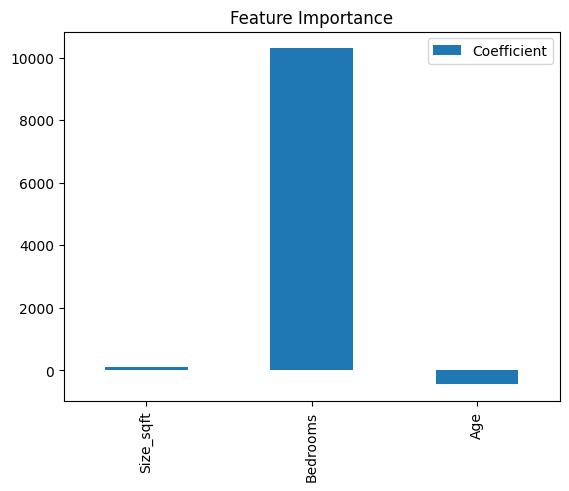

In [29]:
coeff_df.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

In [31]:
result = model.predict([[2000, 3, 5]])
print(result)

[266640.33525605]


C:\Users\manan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
